<a href="https://colab.research.google.com/github/AksharaBasu/GenAI/blob/main/pro1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Libraries installed
✅ Libraries imported
🖥️ Device: cuda
🌾 Built-in agricultural image created


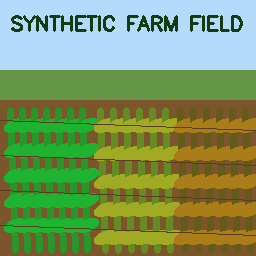

🧠 Synthetic NIR model created
📊 Creating training dataset...
Training images: torch.Size([100, 3, 128, 128])
Training targets: torch.Size([100, 1, 128, 128])

🚀 Training Synthetic NIR Generator...

Epoch 1/5   Loss: 0.054002
Epoch 2/5   Loss: 0.050776
Epoch 3/5   Loss: 0.048573
Epoch 4/5   Loss: 0.049763
Epoch 5/5   Loss: 0.048069

✅ NIR model training completed

🌾 Running built-in sample analysis...

🔍 Analyzing agricultural image...
✅ Analysis completed

PRECISION AGRICULTURE ANALYSIS REPORT

OVERALL CROP CONDITION
HIGH CROP STRESS

------------------------------------------------------------
CROP HEALTH DISTRIBUTION
------------------------------------------------------------

HEALTHY   : 11.47%
MODERATE  : 5.89%
STRESS    : 82.63%

------------------------------------------------------------
NDVI INTERPRETATION
------------------------------------------------------------

NDVI >= 0.60
Healthy vegetation

0.30 <= NDVI < 0.60
Moderate vegetation condition

NDVI < 0.30
Potential crop 

🔍 Analyzing agricultural image...
✅ Analysis completed


In [ ]:
# ============================================================
# PRECISION AGRICULTURE
# Synthetic Multispectral Satellite Imaging
# RGB -> Synthetic NIR -> NDVI -> Crop Health Analysis
# ============================================================

# ============================================================
# 1. INSTALL LIBRARIES
# ============================================================

!pip -q install gradio opencv-python pillow matplotlib numpy torch torchvision

print("✅ Libraries installed")


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms

import gradio as gr

print("✅ Libraries imported")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("🖥️ Device:", device)


# ============================================================
# 3. CREATE BUILT-IN AGRICULTURAL IMAGE
# ============================================================

def create_farm_image(width=256, height=256):

    img = np.zeros((height, width, 3), dtype=np.uint8)

    # Sky
    img[:70, :] = [180, 220, 250]

    # Distant land
    img[70:100, :] = [100, 150, 70]

    # Soil
    img[100:, :] = [125, 85, 45]

    # -------------------------
    # Healthy vegetation
    # -------------------------
    for x in range(10, 90, 12):

        cv2.line(
            img,
            (x, 110),
            (x + 5, 250),
            (40, 150, 40),
            6
        )

        for y in range(125, 245, 25):
            cv2.ellipse(
                img,
                (x + 5, y),
                (12, 6),
                -20,
                0,
                360,
                (30, 180, 50),
                -1
            )

    # -------------------------
    # Moderate vegetation
    # -------------------------
    for x in range(100, 170, 13):

        cv2.line(
            img,
            (x, 110),
            (x + 5, 250),
            (100, 140, 35),
            6
        )

        for y in range(125, 245, 28):
            cv2.ellipse(
                img,
                (x + 5, y),
                (12, 6),
                -20,
                0,
                360,
                (160, 170, 35),
                -1
            )

    # -------------------------
    # Stressed vegetation
    # -------------------------
    for x in range(180, 250, 13):

        cv2.line(
            img,
            (x, 110),
            (x + 5, 250),
            (100, 90, 25),
            6
        )

        for y in range(125, 245, 28):
            cv2.ellipse(
                img,
                (x + 5, y),
                (12, 6),
                -20,
                0,
                360,
                (170, 125, 25),
                -1
            )

    # Soil lines
    for y in range(120, 250, 35):
        cv2.line(
            img,
            (0, y),
            (256, y + 10),
            (90, 60, 35),
            1
        )

    # Title
    cv2.putText(
        img,
        "SYNTHETIC FARM FIELD",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (20, 60, 20),
        2
    )

    return Image.fromarray(img)


# Create built-in image
sample_image = create_farm_image()

print("🌾 Built-in agricultural image created")

display(sample_image)


# ============================================================
# 4. SYNTHETIC NIR GENERATOR
# ============================================================

class SyntheticNIRGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


model = SyntheticNIRGenerator().to(device)

print("🧠 Synthetic NIR model created")


# ============================================================
# 5. CREATE SYNTHETIC TRAINING DATA
# ============================================================

print("📊 Creating training dataset...")

num_images = 100
image_size = 128

X = torch.rand(
    num_images,
    3,
    image_size,
    image_size
)

# RGB channels
red = X[:, 0]
green = X[:, 1]
blue = X[:, 2]

# Simulated vegetation mask
vegetation = (green > red * 0.9).float()

# Increase green vegetation
green = green + vegetation * 0.25
green = torch.clamp(green, 0, 1)

# Synthetic NIR relationship
nir = (
    0.65 * green
    + 0.25 * red
    + 0.10 * (1 - blue)
)

nir = torch.clamp(nir, 0, 1)

Y = nir.unsqueeze(1)

X = X.to(device)
Y = Y.to(device)

print("Training images:", X.shape)
print("Training targets:", Y.shape)


# ============================================================
# 6. TRAIN NIR MODEL
# ============================================================

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 5

print("\n🚀 Training Synthetic NIR Generator...\n")

model.train()

for epoch in range(epochs):

    optimizer.zero_grad()

    output = model(X)

    loss = criterion(output, Y)

    loss.backward()

    optimizer.step()

    print(
        f"Epoch {epoch + 1}/{epochs}   "
        f"Loss: {loss.item():.6f}"
    )

print("\n✅ NIR model training completed")


# ============================================================
# 7. IMAGE TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])


# ============================================================
# 8. GENERATE SYNTHETIC NIR
# ============================================================

def generate_nir(image):

    model.eval()

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        nir = model(image_tensor)

    nir = nir.squeeze().cpu().numpy()

    return nir


# ============================================================
# 9. CALCULATE NDVI
# ============================================================

def calculate_ndvi(image):

    rgb = np.array(image).astype(np.float32) / 255.0

    red = rgb[:, :, 0]

    nir = generate_nir(image)

    ndvi = (nir - red) / (nir + red + 1e-8)

    ndvi = np.clip(ndvi, -1, 1)

    return ndvi


# ============================================================
# 10. CLASSIFY CROP HEALTH
# ============================================================

def classify_crop_health(ndvi):

    healthy = ndvi >= 0.60

    moderate = (
        (ndvi >= 0.30)
        & (ndvi < 0.60)
    )

    stress = ndvi < 0.30

    total = ndvi.size

    healthy_percent = (
        np.sum(healthy) / total
    ) * 100

    moderate_percent = (
        np.sum(moderate) / total
    ) * 100

    stress_percent = (
        np.sum(stress) / total
    ) * 100

    return (
        healthy_percent,
        moderate_percent,
        stress_percent
    )


# ============================================================
# 11. CREATE STRESS MAP
# ============================================================

def create_stress_map(ndvi):

    stress_map = np.zeros(
        (ndvi.shape[0], ndvi.shape[1], 3),
        dtype=np.uint8
    )

    # Healthy = Green
    healthy = ndvi >= 0.60
    stress_map[healthy] = [0, 255, 0]

    # Moderate = Yellow
    moderate = (
        (ndvi >= 0.30)
        & (ndvi < 0.60)
    )

    stress_map[moderate] = [255, 255, 0]

    # Stress = Red
    stress = ndvi < 0.30
    stress_map[stress] = [255, 0, 0]

    return Image.fromarray(stress_map)


# ============================================================
# 12. GENERATE REPORT
# ============================================================

def generate_report(
    healthy_percent,
    moderate_percent,
    stress_percent
):

    if stress_percent > 50:

        overall = "HIGH CROP STRESS"

    elif stress_percent > 25:

        overall = "MODERATE CROP STRESS"

    else:

        overall = "HEALTHY CROP CONDITION"


    report = f"""
============================================================
PRECISION AGRICULTURE ANALYSIS REPORT
============================================================

OVERALL CROP CONDITION
{overall}

------------------------------------------------------------
CROP HEALTH DISTRIBUTION
------------------------------------------------------------

HEALTHY   : {healthy_percent:.2f}%
MODERATE  : {moderate_percent:.2f}%
STRESS    : {stress_percent:.2f}%

------------------------------------------------------------
NDVI INTERPRETATION
------------------------------------------------------------

NDVI >= 0.60
Healthy vegetation

0.30 <= NDVI < 0.60
Moderate vegetation condition

NDVI < 0.30
Potential crop stress

------------------------------------------------------------
RECOMMENDATION
------------------------------------------------------------

Inspect the red/stress regions in the field.

Possible causes include:

• Water shortage
• Nutrient deficiency
• Pest or disease attack
• Soil problems
• Poor vegetation growth

------------------------------------------------------------
AI PIPELINE
------------------------------------------------------------

RGB Image
     ↓
Synthetic NIR Generation
     ↓
NDVI Calculation
     ↓
Crop Health Classification
     ↓
Stress Map
     ↓
Agricultural Report

------------------------------------------------------------
IMPORTANT NOTE
------------------------------------------------------------

This project generates a SYNTHETIC NIR band from RGB imagery.

For real agricultural deployment, calibrated multispectral
satellite imagery containing actual NIR measurements should
be used.

============================================================
"""

    return report


# ============================================================
# 13. ANALYZE IMAGE
# ============================================================

def analyze_image(image):

    print("🔍 Analyzing agricultural image...")

    if image is None:

        return (
            None,
            None,
            None,
            "Please provide an image."
        )

    # Convert to PIL
    if not isinstance(image, Image.Image):

        image = Image.fromarray(image)

    # Generate NIR
    nir = generate_nir(image)

    # Calculate NDVI
    ndvi = calculate_ndvi(image)

    # Health classification
    (
        healthy_percent,
        moderate_percent,
        stress_percent
    ) = classify_crop_health(ndvi)

    # Stress map
    stress_map = create_stress_map(ndvi)

    # --------------------------------------------------------
    # NDVI FIGURE
    # --------------------------------------------------------

    ndvi_fig = plt.figure(
        figsize=(6, 5)
    )

    plt.imshow(
        ndvi,
        cmap="RdYlGn",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(
        label="NDVI"
    )

    plt.title(
        "NDVI Crop Health Map"
    )

    plt.axis("off")

    plt.tight_layout()

    # --------------------------------------------------------
    # NIR FIGURE
    # --------------------------------------------------------

    nir_fig = plt.figure(
        figsize=(6, 5)
    )

    plt.imshow(
        nir,
        cmap="gray"
    )

    plt.colorbar(
        label="Synthetic NIR"
    )

    plt.title(
        "Synthetic NIR Band"
    )

    plt.axis("off")

    plt.tight_layout()

    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    report = generate_report(
        healthy_percent,
        moderate_percent,
        stress_percent
    )

    print("✅ Analysis completed")

    return (
        ndvi_fig,
        nir_fig,
        stress_map,
        report
    )


# ============================================================
# 14. RUN BUILT-IN SAMPLE ANALYSIS
# ============================================================

print("\n🌾 Running built-in sample analysis...\n")

(
    sample_ndvi,
    sample_nir,
    sample_stress,
    sample_report
) = analyze_image(sample_image)

print(sample_report)


# ============================================================
# 15. GRADIO APPLICATION
# ============================================================

print("\n🚀 Starting Gradio application...")


with gr.Blocks(
    title="Precision Agriculture AI"
) as demo:

    gr.Markdown(
        """
        # 🌾 Precision Agriculture AI

        ### Synthetic Multispectral Satellite Imaging

        **RGB → Synthetic NIR → NDVI → Crop Health → Stress Map**
        """
    )

    gr.Markdown(
        """
        Upload an agricultural image or use the built-in
        sample farm image.
        """
    )

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------

    input_image = gr.Image(
        type="pil",
        value=sample_image,
        label="Agricultural Image"
    )

    analyze_button = gr.Button(
        "🔍 Analyze Crop Health",
        variant="primary"
    )

    # --------------------------------------------------------
    # OUTPUT ROW
    # --------------------------------------------------------

    with gr.Row():

        ndvi_output = gr.Plot(
            label="NDVI Crop Health Map"
        )

        nir_output = gr.Plot(
            label="Synthetic NIR"
        )

    # --------------------------------------------------------
    # STRESS MAP
    # --------------------------------------------------------

    stress_output = gr.Image(
        label="Crop Stress Map"
    )

    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    report_output = gr.Textbox(
        label="Agricultural AI Report",
        lines=25
    )

    # --------------------------------------------------------
    # BUTTON ACTION
    # --------------------------------------------------------

    analyze_button.click(
        fn=analyze_image,
        inputs=input_image,
        outputs=[
            ndvi_output,
            nir_output,
            stress_output,
            report_output
        ]
    )

    # Automatically analyze built-in image
    demo.load(
        fn=analyze_image,
        inputs=input_image,
        outputs=[
            ndvi_output,
            nir_output,
            stress_output,
            report_output
        ]
    )


# ============================================================
# 16. LAUNCH
# ============================================================

print("✅ Gradio interface ready")

demo.launch(
    share=True,
    debug=True
)